In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('SampleSuperstore.csv')

In [ ]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [ ]:
df.dtypes

Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [ ]:

df.columns = df.columns.str.strip().str.replace(' ', '_')

print(df.columns)

Index(['Ship_Mode', 'Segment', 'Country', 'City', 'State', 'Postal_Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')


In [ ]:

print(df.columns.tolist())

['Ship_Mode', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']


In [ ]:

print("--- Missing Values ---")
print(df.isnull().sum())

--- Missing Values ---
Ship_Mode       0
Segment         0
Country         0
City            0
State           0
Postal_Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [ ]:
# Duplicate count 
duplicates = df.duplicated().sum()
print(f"\nDuplicates found: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")


Duplicates found: 0


In [ ]:

print("\n--- Basic Stats ---")
print(df[['Sales', 'Profit', 'Quantity']].describe())


--- Basic Stats ---
              Sales      Profit     Quantity
count   9977.000000  9977.00000  9977.000000
mean     230.148902    28.69013     3.790719
std      623.721409   234.45784     2.226657
min        0.444000 -6599.97800     1.000000
25%       17.300000     1.72620     2.000000
50%       54.816000     8.67100     3.000000
75%      209.970000    29.37200     5.000000
max    22638.480000  8399.97600    14.000000


In [ ]:
# Clean data saved as new file
df.to_csv('Sample_Cleaned.csv', index=False)
print("\nCleaned file 'Sample_Cleaned.csv' saved successfully.")


Cleaned file 'Sample_Cleaned.csv' saved successfully.


In [ ]:
# Numerical columnscorrelation 
correlation = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
print("--- Correlation Matrix ---")
print(correlation)

--- Correlation Matrix ---
             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200722 -0.028311  0.479067
Quantity  0.200722  1.000000  0.008678  0.066211
Discount -0.028311  0.008678  1.000000 -0.219662
Profit    0.479067  0.066211 -0.219662  1.000000


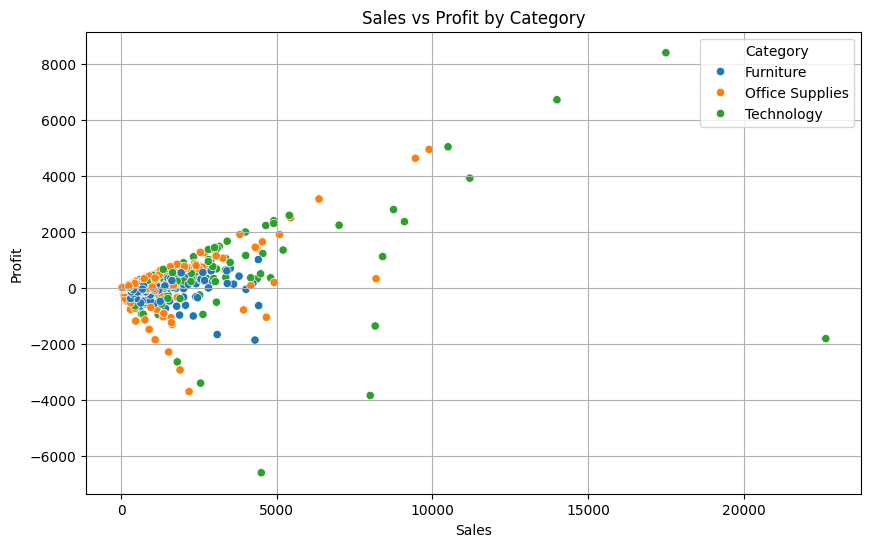

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category')
plt.title('Sales vs Profit by Category')
plt.grid(True)
plt.show()

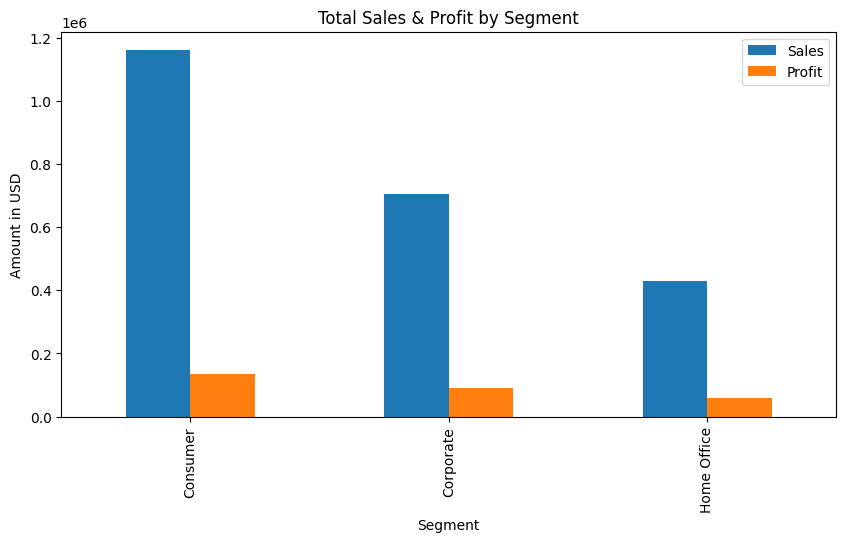

In [ ]:
# Segment wise Profit and Sales visualization
segment_data = df.groupby('Segment')[['Sales', 'Profit']].sum()
segment_data.plot(kind='bar', figsize=(10,5))
plt.title('Total Sales & Profit by Segment')
plt.ylabel('Amount in USD')
plt.show()

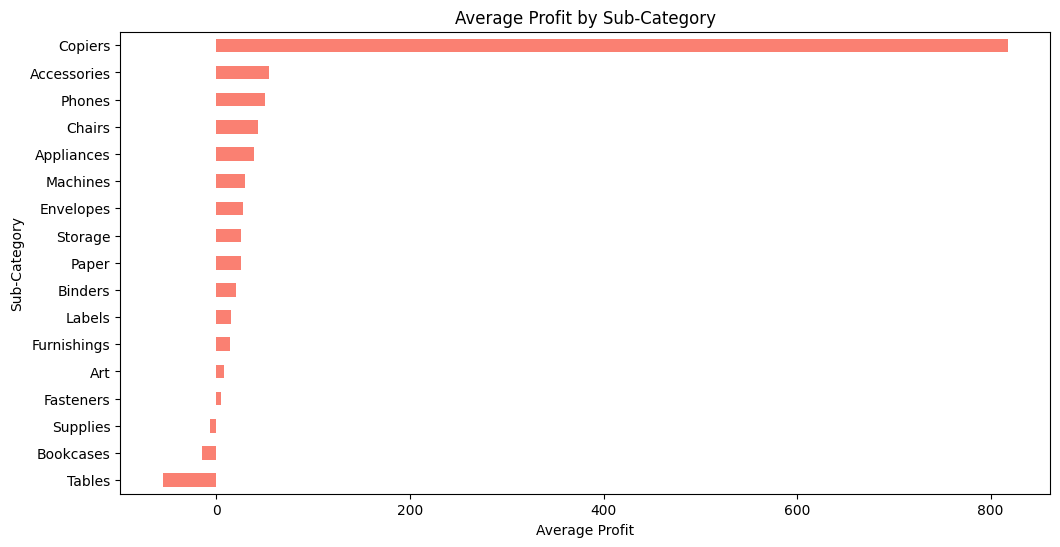

In [ ]:
# Sub-category wise average profit 
plt.figure(figsize=(12,6))
df.groupby('Sub-Category')['Profit'].mean().sort_values().plot(kind='barh', color='salmon')
plt.title('Average Profit by Sub-Category')
plt.xlabel('Average Profit')
plt.show()

In [ ]:
# State wise Discount andProfit analysis
state_analysis = df.groupby('State').agg({'Discount': 'mean', 'Profit': 'sum'}).sort_values(by='Discount', ascending=False)
print(state_analysis.head(10))

                Discount      Profit
State                               
Illinois        0.389206 -12601.6500
Texas           0.370539 -25750.9833
Pennsylvania    0.328840 -15565.4035
Ohio            0.325000 -16959.3178
Colorado        0.316484  -6527.8579
Arizona         0.303571  -3427.9246
Florida         0.299347  -3399.3017
Tennessee       0.291257  -5341.6936
Oregon          0.289431  -1194.0993
North Carolina  0.283534  -7490.9122


In [ ]:
# Texas (The highest loss state) 
texas_data = df[df['State'] == 'Texas']

texas_analysis = texas_data.groupby('Category')[['Sales', 'Profit']].sum()
print(texas_analysis)

                      Sales      Profit
Category                               
Furniture        60593.2918 -10436.1419
Office Supplies  44427.0260 -18606.2704
Technology       65104.2240   3291.4290


In [ ]:

multi_analysis = df.groupby(['State', 'Category'])['Profit'].sum().reset_index()

print(multi_analysis.sort_values(by='Profit').head(10))

              State         Category      Profit
122           Texas  Office Supplies -18606.2704
99             Ohio       Technology -12649.9401
121           Texas        Furniture -10436.1419
33         Illinois        Furniture  -9076.2894
34         Illinois  Office Supplies  -8347.9198
106    Pennsylvania        Furniture  -7196.7199
107    Pennsylvania  Office Supplies  -5177.4620
97             Ohio        Furniture  -4194.2624
95   North Carolina       Technology  -3583.3040
93   North Carolina        Furniture  -3486.4633


C:\Users\dell\AppData\Local\Temp\ipykernel_16916\3682228382.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=texas_only, x='Category', y='Profit', estimator=sum, ci=None, palette='Reds_r')
C:\Users\dell\AppData\Local\Temp\ipykernel_16916\3682228382.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=texas_only, x='Category', y='Profit', estimator=sum, ci=None, palette='Reds_r')


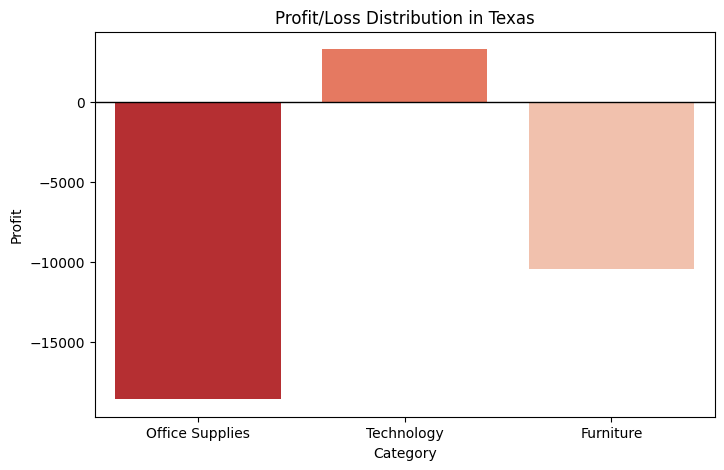

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

texas_only = df[df['State'] == 'Texas']

# Category wise Profit's Bar Plot
plt.figure(figsize=(8,5))
sns.barplot(data=texas_only, x='Category', y='Profit', estimator=sum, ci=None, palette='Reds_r')
plt.title('Profit/Loss Distribution in Texas')
plt.axhline(0, color='black', linewidth=1) # Zero line
plt.show()

In [ ]:
def get_state_report(state_name):
    
    # 1. Filter State data
    state_df = df[df['State'] == state_name]
    
    if state_df.empty:
        return f"Error: State '{state_name}' not found in dataset."

    # 2. Calculate Key Metrics
    total_sales = state_df['Sales'].sum()
    total_profit = state_df['Profit'].sum()
    avg_discount = state_df['Discount'].mean()
    margin = (total_profit / total_sales) * 100

    # 3. Identify the Worst Category in that State
    worst_cat = state_df.groupby('Category')['Profit'].sum().idxmin()
    worst_profit = state_df.groupby('Category')['Profit'].sum().min()

    # 4. Print the Report
    print(f"--- 🏥 Health Report for {state_name} ---")
    print(f"Total Sales   : ${total_sales:,.2f}")
    print(f"Total Profit  : ${total_profit:,.2f}")
    print(f"Avg Discount  : {avg_discount*100:.2f}%")
    print(f"Profit Margin : {margin:.2f}%")
    print(f"Major Issue   : {worst_cat} is losing ${abs(worst_profit):,.2f}")
    print("-" * 35)

get_state_report('Texas')
get_state_report('California')

--- 🏥 Health Report for Ohio ---
Total Sales   : $77,976.76
Total Profit  : $-16,959.32
Avg Discount  : 32.50%
Profit Margin : -21.75%
Major Issue   : Technology is losing $12,649.94
-----------------------------------
--- 🏥 Health Report for California ---
Total Sales   : $457,576.27
Total Profit  : $76,330.79
Avg Discount  : 7.29%
Profit Margin : 16.68%
Major Issue   : Furniture is losing $9,162.97
-----------------------------------


In [ ]:
unique_states = df['State'].unique()
print(unique_states)
all_states = df['State'].unique()

print("🚨 STATES WITH NEGATIVE PROFIT 🚨\n")
for s in all_states:
    state_profit = df[df['State'] == s]['Profit'].sum()
    if state_profit < 0:
        get_state_report(s)

🚨 STATES WITH NEGATIVE PROFIT 🚨

--- 🏥 Health Report for Florida ---
Total Sales   : $89,473.71
Total Profit  : $-3,399.30
Avg Discount  : 29.93%
Profit Margin : -3.80%
Major Issue   : Furniture is losing $2,254.98
-----------------------------------
--- 🏥 Health Report for North Carolina ---
Total Sales   : $55,603.16
Total Profit  : $-7,490.91
Avg Discount  : 28.35%
Profit Margin : -13.47%
Major Issue   : Technology is losing $3,583.30
-----------------------------------
--- 🏥 Health Report for Texas ---
Total Sales   : $170,124.54
Total Profit  : $-25,750.98
Avg Discount  : 37.05%
Profit Margin : -15.14%
Major Issue   : Office Supplies is losing $18,606.27
-----------------------------------
--- 🏥 Health Report for Pennsylvania ---
Total Sales   : $116,496.36
Total Profit  : $-15,565.40
Avg Discount  : 32.88%
Profit Margin : -13.36%
Major Issue   : Furniture is losing $7,196.72
-----------------------------------
--- 🏥 Health Report for Illinois ---
Total Sales   : $80,162.54
Total 